In [1]:
import os
import numpy as np
import xarray as xr
from scipy import ndimage
import glob

In [2]:
input_file = "/ocean/dtaneja/MOAD/analysis-dishika/notebooks/predictions/daily_downscaled_2008/downscaled_y2008m01d01.nc"
output_dir = "/ocean/dtaneja/MOAD/analysis-dishika/notebooks/predictions/daily_downscaled_2008_padded_test"
output_file = os.path.join(output_dir, "downscaled_y2008m01d01_padded.nc")

os.makedirs(output_dir, exist_ok=True)

In [3]:
with xr.open_dataset(input_file) as recon_open:
    recon = recon_open.load()

print(recon)

variables = ["qair", "therm_rad", "precip", "atmpres", "solar", "tair", "u_wind", "v_wind"]
my_values = {}
for var in variables:
    my_values[var] = np.zeros((8, 898 + 20, 398 + 20))
    my_values[var][:, 10:-10, 10:-10] = recon[var].values

<xarray.Dataset> Size: 95MB
Dimensions:       (time_counter: 8, y: 898, x: 398)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 64B 2008-01-01 ... 2008-01-01...
Dimensions without coordinates: y, x
Data variables:
    qair          (time_counter, y, x) float32 11MB nan nan nan ... nan nan nan
    therm_rad     (time_counter, y, x) float32 11MB nan nan nan ... nan nan nan
    precip        (time_counter, y, x) float32 11MB nan nan nan ... nan nan nan
    atmpres       (time_counter, y, x) float32 11MB nan nan nan ... nan nan nan
    solar         (time_counter, y, x) float32 11MB nan nan nan ... nan nan nan
    tair          (time_counter, y, x) float32 11MB nan nan nan ... nan nan nan
    u_wind        (time_counter, y, x) float32 11MB nan nan nan ... nan nan nan
    v_wind        (time_counter, y, x) float32 11MB nan nan nan ... nan nan nan
    nav_lat       (y, x) float32 1MB 46.86 46.86 46.86 46.87 ... 51.1 51.1 51.1
    nav_lon       (y, x) float32 1MB -123.4 -123.4 -1

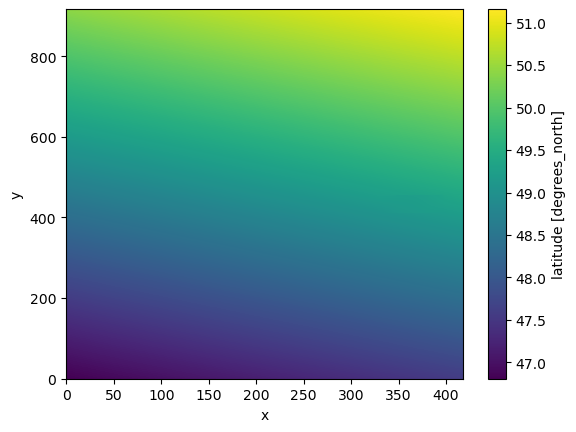

In [4]:
my_tmask = recon["tmask"].pad(pad_width={"x": (10, 10), "y": (10, 10)}, mode="constant", constant_values=0)

my_nav_lat = recon["nav_lat"].pad(pad_width={"x": (10, 10), "y": (10, 10)}, mode="constant", constant_values=0)

for jj in range(10, 398 + 10):
    m = (my_nav_lat[20, jj] - my_nav_lat[10, jj]) / 10.0
    b = my_nav_lat[10, jj]
    for ii in range(0, 10):
        my_nav_lat[ii, jj] = b + m * (ii - 10)

for jj in range(10, 398 + 10):
    m = (my_nav_lat[898 + 9, jj] - my_nav_lat[898 + 9 - 10, jj]) / 10.0
    b = my_nav_lat[898 + 9, jj]
    for ii in range(898 + 10, 898 + 20):
        my_nav_lat[ii, jj] = b + m * (ii - (898 + 9))

for ii in range(0, 898 + 20):
    m = (my_nav_lat[ii, 20] - my_nav_lat[ii, 10]) / 10.0
    b = my_nav_lat[ii, 10]
    for jj in range(0, 10):
        my_nav_lat[ii, jj] = b + m * (jj - 10)

    m = (my_nav_lat[ii, 398 + 9] - my_nav_lat[ii, 398 + 9 - 10]) / 10.0
    b = my_nav_lat[ii, 398 + 9]
    for jj in range(398 + 10, 398 + 20):
        my_nav_lat[ii, jj] = b + m * (jj - (398 + 9))

my_nav_lat.plot()

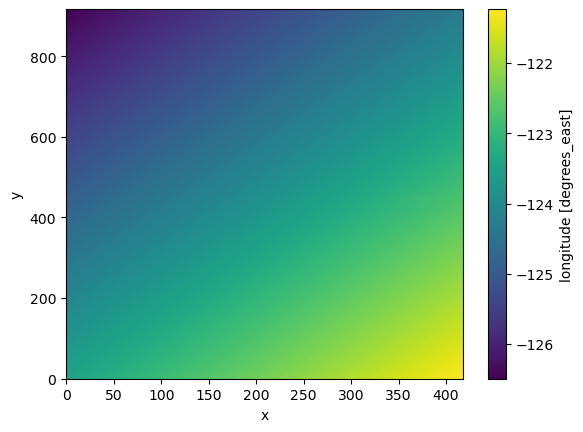

In [5]:
my_nav_lon = recon["nav_lon"].pad(pad_width={"x": (10, 10), "y": (10, 10)}, mode="constant", constant_values=0)

for ii in range(10, 898 + 10):
    m = (my_nav_lon[ii, 20] - my_nav_lon[ii, 10]) / 10.0
    b = my_nav_lon[ii, 10]
    for jj in range(0, 10):
        my_nav_lon[ii, jj] = b + m * (jj - 10)

for ii in range(10, 898 + 10):
    m = (my_nav_lon[ii, 398 + 9] - my_nav_lon[ii, 398 + 9 - 10]) / 10.0
    b = my_nav_lon[ii, 398 + 9]
    for jj in range(398 + 10, 398 + 20):
        my_nav_lon[ii, jj] = b + m * (jj - (398 + 9))

for jj in range(0, 398 + 20):
    m = (my_nav_lon[20, jj] - my_nav_lon[10, jj]) / 10.0
    b = my_nav_lon[10, jj]
    for ii in range(0, 10):
        my_nav_lon[ii, jj] = b + m * (ii - 10)

    m = (my_nav_lon[898 + 9, jj] - my_nav_lon[898 + 9 - 10, jj]) / 10.0
    b = my_nav_lon[898 + 9, jj]
    for ii in range(898 + 10, 898 + 20):
        my_nav_lon[ii, jj] = b + m * (ii - (898 + 9))

my_nav_lon.plot()

In [6]:
ds = xr.Dataset(
    data_vars={
        **{var: (["time_counter", "y", "x"], my_values[var]) for var in variables},
        "tmask": (["y", "x"], my_tmask.values),
        "nav_lat": (["y", "x"], my_nav_lat.values),
        "nav_lon": (["y", "x"], my_nav_lon.values),
    },
    coords={
        "time_counter": recon.time_counter,
    },
    attrs=recon.attrs,
)

In [7]:
print(ds)

print("qair shape:", ds["qair"].shape)
print("tmask shape:", ds["tmask"].shape)
print("nav_lat shape:", ds["nav_lat"].shape)
print("nav_lon shape:", ds["nav_lon"].shape)

ds.to_netcdf(output_file)

print("Padded file saved to:")
print(output_file)

<xarray.Dataset> Size: 200MB
Dimensions:       (time_counter: 8, y: 918, x: 418)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 64B 2008-01-01 ... 2008-01-01...
Dimensions without coordinates: y, x
Data variables:
    qair          (time_counter, y, x) float64 25MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    therm_rad     (time_counter, y, x) float64 25MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    precip        (time_counter, y, x) float64 25MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    atmpres       (time_counter, y, x) float64 25MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    solar         (time_counter, y, x) float64 25MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    tair          (time_counter, y, x) float64 25MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    u_wind        (time_counter, y, x) float64 25MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    v_wind        (time_counter, y, x) float64 25MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    tmask         (y, x) int8 384kB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
    nav_lat       (y, x) float32 2MB 46.81 46.81 46.

In [8]:
input_file = "/ocean/dtaneja/MOAD/analysis-dishika/notebooks/predictions/daily_downscaled_2008_padded_test/downscaled_y2008m01d01_padded.nc"
output_dir = "/ocean/dtaneja/MOAD/analysis-dishika/notebooks/predictions/daily_downscaled_2008_padded_test"
output_file = os.path.join(output_dir, "downscaled_y2008m01d01_padded_land_extended.nc")

os.makedirs(output_dir, exist_ok=True)

In [9]:
variables = ["qair", "therm_rad", "precip", "atmpres", "solar", "tair", "u_wind", "v_wind"]

In [10]:
with xr.open_dataset(input_file) as opened_dataset:
    ds = opened_dataset.load()

tmask = ds["tmask"].squeeze(drop=True).transpose("y", "x").values

print("tmask shape:", tmask.shape)
print("Water cells:", np.sum(tmask == 1))
print("Land cells:", np.sum(tmask == 0))

mask = 1 - tmask
mask = mask.astype(bool)

tmask shape: (918, 418)
Water cells: 81383
Land cells: 302341


In [11]:
for extension_number in range(3):
    eroded_mask = ndimage.binary_erosion(mask)
    rim = mask.astype(np.int8) - eroded_mask.astype(np.int8)
    rim = rim.astype(bool)

    print()
    print("Extension step:", extension_number + 1)
    print("Number of cells in rim:", np.sum(rim))

    for var in variables:
        variable_attrs = ds[var].attrs.copy()
        variable_data = ds[var].transpose("time_counter", "y", "x").values.copy()
        number_filled = 0

        for time_index in range(variable_data.shape[0]):
            field = variable_data[time_index]
            missing_values = ~np.isfinite(field)
            rim_missing_values = rim & missing_values

            if not np.any(rim_missing_values):
                continue

            if not np.any(np.isfinite(field)):
                raise ValueError(f"No finite values are available for {var} at time index {time_index}")

            nearest_indices = ndimage.distance_transform_edt(missing_values, return_distances=False, return_indices=True)
            nearest_y = nearest_indices[0]
            nearest_x = nearest_indices[1]

            field[rim_missing_values] = field[nearest_y[rim_missing_values], nearest_x[rim_missing_values]]
            variable_data[time_index] = field
            number_filled += np.sum(rim_missing_values)

        ds[var] = xr.DataArray(variable_data, dims=("time_counter", "y", "x"), coords={"time_counter": ds["time_counter"], "y": ds["y"], "x": ds["x"]}, attrs=variable_attrs)

        print(var, "filled cells:", number_filled)

    mask = eroded_mask

print()
print("Replacing remaining NaNs with zeros")

for var in variables:
    variable_data = ds[var].values.copy()
    number_of_nans = np.isnan(variable_data).sum()
    variable_data[np.isnan(variable_data)] = 0
    ds[var].values[:] = variable_data
    print(var, "NaNs replaced with zero:", number_of_nans)

ds.to_netcdf(output_file, unlimited_dims=["time_counter"])

print()
print("File successfully saved:")
print(output_file)


Extension step: 1
Number of cells in rim: 13652
qair filled cells: 87872
therm_rad filled cells: 87872
precip filled cells: 87872
atmpres filled cells: 87872
solar filled cells: 87872
tair filled cells: 87872
u_wind filled cells: 87872
v_wind filled cells: 87872

Extension step: 2
Number of cells in rim: 12280
qair filled cells: 76056
therm_rad filled cells: 76056
precip filled cells: 76056
atmpres filled cells: 76056
solar filled cells: 76056
tair filled cells: 76056
u_wind filled cells: 76056
v_wind filled cells: 76056

Extension step: 3
Number of cells in rim: 11163
qair filled cells: 67056
therm_rad filled cells: 67056
precip filled cells: 67056
atmpres filled cells: 67056
solar filled cells: 67056
tair filled cells: 67056
u_wind filled cells: 67056
v_wind filled cells: 67056

Replacing remaining NaNs with zeros
qair NaNs replaced with zero: 1977184
therm_rad NaNs replaced with zero: 1977184
precip NaNs replaced with zero: 1977184
atmpres NaNs replaced with zero: 1977184
solar NaN

In [12]:
ds = xr.open_dataset("/ocean/dtaneja/MOAD/analysis-dishika/notebooks/predictions/daily_downscaled_2008_padded_test/downscaled_y2008m01d01_padded_land_extended.nc")
ds

<xarray.Dataset> Size: 200MB
Dimensions:       (time_counter: 8, y: 918, x: 418)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 64B 2008-01-01 ... 2008-01-01...
  * y             (y) int64 7kB 0 1 2 3 4 5 6 7 ... 911 912 913 914 915 916 917
  * x             (x) int64 3kB 0 1 2 3 4 5 6 7 ... 411 412 413 414 415 416 417
Data variables:
    qair          (time_counter, y, x) float64 25MB ...
    therm_rad     (time_counter, y, x) float64 25MB ...
    precip        (time_counter, y, x) float64 25MB ...
    atmpres       (time_counter, y, x) float64 25MB ...
    solar         (time_counter, y, x) float64 25MB ...
    tair          (time_counter, y, x) float64 25MB ...
    u_wind        (time_counter, y, x) float64 25MB ...
    v_wind        (time_counter, y, x) float64 25MB ...
    tmask         (y, x) int8 384kB ...
    nav_lat       (y, x) float32 2MB ...
    nav_lon       (y, x) float32 2MB ...
Attributes:
    title:                 PCA and multiple linear regression downscaled atmo...
    data_split:            validation
    year:                  2008
    time_resolution:       3-hourly
    notebook_github_url:   https://github.com/SalishSeaCast/analysis-dishika/...
    source_files:          pred_humidity_2008.nc, pred_longwave_rad_2008.nc, ...
    note:                  Each output file contains all available downscaled...
    date:                  2008-01-01
    number_of_timestamps:  8

In [13]:
input_dir = "/ocean/dtaneja/MOAD/analysis-dishika/notebooks/predictions/daily_downscaled_2008"
output_dir = "/ocean/dtaneja/MOAD/analysis-dishika/notebooks/predictions/daily_downscaled_2008_padded"
os.makedirs(output_dir, exist_ok=True)

In [14]:
input_files = sorted(glob.glob(os.path.join(input_dir, "downscaled_y2008m??d??.nc")))
variables = ["qair", "therm_rad", "precip", "atmpres", "solar", "tair", "u_wind", "v_wind"]

print("Total files found:", len(input_files))

if len(input_files) != 365:
    raise ValueError(f"Expected 365 total files, but found {len(input_files)}")

Total files found: 365


In [15]:
for file_number, input_file in enumerate(input_files, start=1):
    filename = os.path.basename(input_file)
    output_file = os.path.join(output_dir, filename)

    print()
    print("=" * 70)
    print(f"Processing file {file_number}/{len(input_files)}")
    print("Input:", input_file)
    print("Output:", output_file)

    with xr.open_dataset(input_file) as recon_open:
        recon = recon_open.load()

    if recon.sizes["time_counter"] != 8:
        raise ValueError(f"{filename} has {recon.sizes['time_counter']} timestamps instead of 8")

    my_values = {}

    for var in variables:
        my_values[var] = np.zeros((8, 898 + 20, 398 + 20), dtype=recon[var].dtype)
        my_values[var][:, 10:-10, 10:-10] = recon[var].values

    my_tmask = recon["tmask"].pad(pad_width={"x": (10, 10), "y": (10, 10)}, mode="constant", constant_values=0)

    my_nav_lat = recon["nav_lat"].pad(pad_width={"x": (10, 10), "y": (10, 10)}, mode="constant", constant_values=0)

    for jj in range(10, 398 + 10):
        m = (my_nav_lat[20, jj] - my_nav_lat[10, jj]) / 10.0
        b = my_nav_lat[10, jj]
        for ii in range(0, 10):
            my_nav_lat[ii, jj] = b + m * (ii - 10)

    for jj in range(10, 398 + 10):
        m = (my_nav_lat[898 + 9, jj] - my_nav_lat[898 + 9 - 10, jj]) / 10.0
        b = my_nav_lat[898 + 9, jj]
        for ii in range(898 + 10, 898 + 20):
            my_nav_lat[ii, jj] = b + m * (ii - (898 + 9))

    for ii in range(0, 898 + 20):
        m = (my_nav_lat[ii, 20] - my_nav_lat[ii, 10]) / 10.0
        b = my_nav_lat[ii, 10]
        for jj in range(0, 10):
            my_nav_lat[ii, jj] = b + m * (jj - 10)

        m = (my_nav_lat[ii, 398 + 9] - my_nav_lat[ii, 398 + 9 - 10]) / 10.0
        b = my_nav_lat[ii, 398 + 9]
        for jj in range(398 + 10, 398 + 20):
            my_nav_lat[ii, jj] = b + m * (jj - (398 + 9))

    my_nav_lon = recon["nav_lon"].pad(pad_width={"x": (10, 10), "y": (10, 10)}, mode="constant", constant_values=0)

    for ii in range(10, 898 + 10):
        m = (my_nav_lon[ii, 20] - my_nav_lon[ii, 10]) / 10.0
        b = my_nav_lon[ii, 10]
        for jj in range(0, 10):
            my_nav_lon[ii, jj] = b + m * (jj - 10)

    for ii in range(10, 898 + 10):
        m = (my_nav_lon[ii, 398 + 9] - my_nav_lon[ii, 398 + 9 - 10]) / 10.0
        b = my_nav_lon[ii, 398 + 9]
        for jj in range(398 + 10, 398 + 20):
            my_nav_lon[ii, jj] = b + m * (jj - (398 + 9))

    for jj in range(0, 398 + 20):
        m = (my_nav_lon[20, jj] - my_nav_lon[10, jj]) / 10.0
        b = my_nav_lon[10, jj]
        for ii in range(0, 10):
            my_nav_lon[ii, jj] = b + m * (ii - 10)

        m = (my_nav_lon[898 + 9, jj] - my_nav_lon[898 + 9 - 10, jj]) / 10.0
        b = my_nav_lon[898 + 9, jj]
        for ii in range(898 + 10, 898 + 20):
            my_nav_lon[ii, jj] = b + m * (ii - (898 + 9))

    ds = xr.Dataset(
        data_vars={
            **{var: (["time_counter", "y", "x"], my_values[var], recon[var].attrs.copy()) for var in variables},
            "tmask": (["y", "x"], my_tmask.values, recon["tmask"].attrs.copy()),
            "nav_lat": (["y", "x"], my_nav_lat.values, recon["nav_lat"].attrs.copy()),
            "nav_lon": (["y", "x"], my_nav_lon.values, recon["nav_lon"].attrs.copy()),
        },
        coords={
            "time_counter": recon["time_counter"].values,
            "y": np.arange(898 + 20),
            "x": np.arange(398 + 20),
        },
        attrs=recon.attrs.copy(),
    )

    ds["time_counter"].attrs = recon["time_counter"].attrs.copy()

    tmask = ds["tmask"].squeeze(drop=True).transpose("y", "x").values
    mask = 1 - tmask
    mask = mask.astype(bool)

    for extension_number in range(3):
        eroded_mask = ndimage.binary_erosion(mask)
        rim = mask.astype(np.int8) - eroded_mask.astype(np.int8)
        rim = rim.astype(bool)

        print("Extension step:", extension_number + 1)
        print("Number of cells in rim:", np.sum(rim))

        for var in variables:
            variable_attrs = ds[var].attrs.copy()
            variable_data = ds[var].transpose("time_counter", "y", "x").values.copy()
            number_filled = 0

            for time_index in range(variable_data.shape[0]):
                field = variable_data[time_index]
                missing_values = ~np.isfinite(field)
                rim_missing_values = rim & missing_values

                if not np.any(rim_missing_values):
                    continue

                if not np.any(np.isfinite(field)):
                    raise ValueError(f"No finite values are available for {var} at time index {time_index} in {filename}")

                nearest_indices = ndimage.distance_transform_edt(missing_values, return_distances=False, return_indices=True)
                nearest_y = nearest_indices[0]
                nearest_x = nearest_indices[1]

                field[rim_missing_values] = field[nearest_y[rim_missing_values], nearest_x[rim_missing_values]]
                variable_data[time_index] = field
                number_filled += np.sum(rim_missing_values)

            ds[var] = xr.DataArray(variable_data, dims=("time_counter", "y", "x"), coords={"time_counter": ds["time_counter"], "y": ds["y"], "x": ds["x"]}, attrs=variable_attrs)

            print(var, "filled cells:", number_filled)

        mask = eroded_mask

    print("Replacing remaining NaNs with zeros")

    for var in variables:
        variable_data = ds[var].values.copy()
        number_of_nans = np.isnan(variable_data).sum()
        variable_data[np.isnan(variable_data)] = 0
        ds[var].values[:] = variable_data
        print(var, "NaNs replaced with zero:", number_of_nans)

    for var in variables:
        if np.isnan(ds[var].values).any():
            raise ValueError(f"{var} still contains NaNs in {filename}")

        if ds[var].shape != (8, 918, 418):
            raise ValueError(f"{var} has unexpected shape {ds[var].shape} in {filename}")

    ds.to_netcdf(output_file, mode="w", unlimited_dims=["time_counter"])

    print("Successfully saved:", output_file)

    ds.close()
    recon.close()

print()
print("Finished processing all 2008 files.")
print("Output directory:")
print(output_dir)


Processing file 1/365
Input: /ocean/dtaneja/MOAD/analysis-dishika/notebooks/predictions/daily_downscaled_2008/downscaled_y2008m01d01.nc
Output: /ocean/dtaneja/MOAD/analysis-dishika/notebooks/predictions/daily_downscaled_2008_padded/downscaled_y2008m01d01.nc
Extension step: 1
Number of cells in rim: 13652
qair filled cells: 87872
therm_rad filled cells: 87872
precip filled cells: 87872
atmpres filled cells: 87872
solar filled cells: 87872
tair filled cells: 87872
u_wind filled cells: 87872
v_wind filled cells: 87872
Extension step: 2
Number of cells in rim: 12280
qair filled cells: 76056
therm_rad filled cells: 76056
precip filled cells: 76056
atmpres filled cells: 76056
solar filled cells: 76056
tair filled cells: 76056
u_wind filled cells: 76056
v_wind filled cells: 76056
Extension step: 3
Number of cells in rim: 11163
qair filled cells: 67056
therm_rad filled cells: 67056
precip filled cells: 67056
atmpres filled cells: 67056
solar filled cells: 67056
tair filled cells: 67056
u_wind